In [5]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_test = np.load('X_test.npy')
y_test = np.load('y_test.npy')

In [3]:
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [6]:
class DeepCNN(nn.Module):
    def __init__(self, dropout_rate, dense_units):
        super(DeepCNN, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1),nn.ReLU()
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, dense_units),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(dense_units, 29)
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.fc_block(x)
        return x


In [7]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()
        self.conv_block = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        self.fc_block = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 29)
        )

    def forward(self, x):
        return self.fc_block(self.conv_block(x))

In [6]:
def evaluate_model(model, model_name):
    model.eval()
    all_preds = []
    
    with torch.no_grad():
        # Get predictions in batches
        batch_size = 64
        for i in range(0, len(X_test), batch_size):
            X_batch = X_test[i:i+batch_size]
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
    
    all_preds = np.array(all_preds)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, all_preds)
    precision = precision_score(y_test, all_preds, average='weighted', zero_division=0)
    recall = recall_score(y_test, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(y_test, all_preds, average='weighted', zero_division=0)
    
    print(f"\n{model_name} Results:")
    print(f"  Accuracy:  {accuracy*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1 Score:  {f1*100:.2f}%")
    
    return {
        'name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': all_preds
    }

In [7]:
print("\n===== Evaluating Model V1 =====")
model_v1 = DeepCNN(dropout_rate=0.3, dense_units=128)
model_v1.load_state_dict(torch.load('model_v1.pth'))
results_v1 = evaluate_model(model_v1, "Model V1 (dropout=0.3, dense=128)")



===== Evaluating Model V1 =====

Model V1 (dropout=0.3, dense=128) Results:
  Accuracy:  99.71%
  Precision: 99.71%
  Recall:    99.71%
  F1 Score:  99.71%


In [8]:
print("\n===== Evaluating Model V2 =====")
model_v2 = DeepCNN(dropout_rate=0.5, dense_units=128)
model_v2.load_state_dict(torch.load('model_v2.pth'))
results_v2 = evaluate_model(model_v2, "Model V2 (dropout=0.5, dense=128)")


===== Evaluating Model V2 =====

Model V2 (dropout=0.5, dense=128) Results:
  Accuracy:  99.17%
  Precision: 99.19%
  Recall:    99.17%
  F1 Score:  99.17%


In [9]:
print("\n===== Evaluating Model V3 =====")
model_v3 = DeepCNN(dropout_rate=0.5, dense_units=256)
model_v3.load_state_dict(torch.load('model_v3.pth'))
results_v3 = evaluate_model(model_v3, "Model V3 (dropout=0.5, dense=256)")


===== Evaluating Model V3 =====

Model V3 (dropout=0.5, dense=256) Results:
  Accuracy:  99.90%
  Precision: 99.90%
  Recall:    99.90%
  F1 Score:  99.90%


In [10]:
print("\n===== Evaluating Model Person 3 (BatchNorm) =====")
model_p3 = BatchNormCNN()
model_p3.load_state_dict(torch.load('model_person3.pth'))
results_p3 = evaluate_model(model_p3, "Model Person 3 (BatchNorm CNN)")


===== Evaluating Model Person 3 (BatchNorm) =====

Model Person 3 (BatchNorm CNN) Results:
  Accuracy:  99.06%
  Precision: 99.08%
  Recall:    99.06%
  F1 Score:  99.06%


In [11]:
print("\n\n" + "="*70)
print("COMPARISON TABLE")
print("="*70)
print(f"{'Model':<35} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1 Score':<12}")
print("-"*70)

all_results = [results_v1, results_v2, results_v3, results_p3]
for r in all_results:
    print(f"{r['name']:<35} {r['accuracy']*100:>10.2f}% {r['precision']*100:>10.2f}% {r['recall']*100:>10.2f}% {r['f1']*100:>10.2f}%")

# Find best model
best_model = max(all_results, key=lambda x: x['f1'])
print("\n" + "="*70)
print(f"WINNER: {best_model['name']} with F1 Score of {best_model['f1']*100:.2f}%")
print("="*70)




COMPARISON TABLE
Model                               Accuracy     Precision    Recall       F1 Score    
----------------------------------------------------------------------
Model V1 (dropout=0.3, dense=128)        99.71%      99.71%      99.71%      99.71%
Model V2 (dropout=0.5, dense=128)        99.17%      99.19%      99.17%      99.17%
Model V3 (dropout=0.5, dense=256)        99.90%      99.90%      99.90%      99.90%
Model Person 3 (BatchNorm CNN)           99.06%      99.08%      99.06%      99.06%

WINNER: Model V3 (dropout=0.5, dense=256) with F1 Score of 99.90%



Confusion matrix saved as 'confusion_matrix_best_model.png'


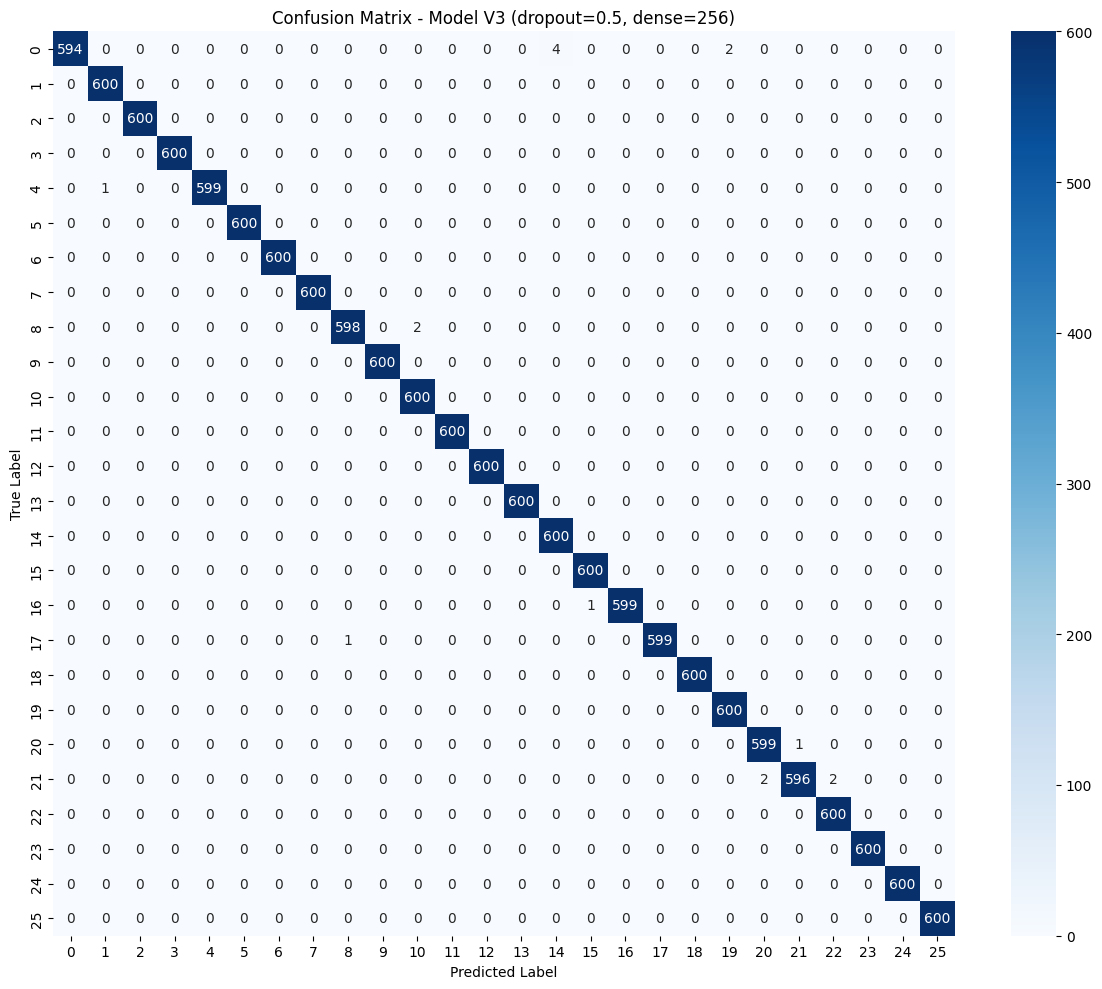

In [20]:
cm = confusion_matrix(y_test, best_model['predictions'])

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'Confusion Matrix - {best_model["name"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_best_model.png', dpi=300)
print("\nConfusion matrix saved as 'confusion_matrix_best_model.png'")

In [15]:
unique_classes = np.unique(y_test)
print(f"\nClasses in test set: {len(unique_classes)}")
print(f"Class labels: {unique_classes}")

if len(unique_classes) < 29:
    print(f"WARNING: Only {len(unique_classes)} classes in test set (expected 29)")
    missing_classes = set(range(29)) - set(unique_classes)
    print(f"Missing classes: {missing_classes}")


Classes in test set: 26
Class labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]
Missing classes: {26, 27, 28}


In [16]:
# Identify most confused pairs
print("\n===== CONFUSION ANALYSIS =====")
print(f"Confusion matrix shape: {cm.shape}")

# Get actual number of classes in confusion matrix
num_classes = cm.shape[0]

np.fill_diagonal(cm, 0)  # Remove correct predictions
confused_pairs = []

for i in range(num_classes):  # ← Changed from range(29)
    for j in range(num_classes):  # ← Changed from range(29)
        if cm[i, j] > 5:  # Only show confusions that happen more than 5 times
            confused_pairs.append((i, j, cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print("\nMost Confused Letter Pairs (True → Predicted):")
if len(confused_pairs) > 0:
    for true_label, pred_label, count in confused_pairs[:10]:
        print(f"  Letter {true_label} → Letter {pred_label}: {count} times")
else:
    print("  No significant confusions found (all confusions < 5 occurrences)")
    
    # Show smaller confusions instead
    confused_pairs_small = []
    for i in range(num_classes):
        for j in range(num_classes):
            if i != j and cm[i, j] > 0:
                confused_pairs_small.append((i, j, cm[i, j]))
    
    confused_pairs_small.sort(key=lambda x: x[2], reverse=True)
    
    print("\nTop confusions (any amount):")
    for true_label, pred_label, count in confused_pairs_small[:10]:
        print(f"  Letter {true_label} → Letter {pred_label}: {count} times")


===== CONFUSION ANALYSIS =====
Confusion matrix shape: (26, 26)

Most Confused Letter Pairs (True → Predicted):
  No significant confusions found (all confusions < 5 occurrences)

Top confusions (any amount):
  Letter 0 → Letter 14: 4 times
  Letter 0 → Letter 19: 2 times
  Letter 8 → Letter 10: 2 times
  Letter 21 → Letter 20: 2 times
  Letter 21 → Letter 22: 2 times
  Letter 4 → Letter 1: 1 times
  Letter 16 → Letter 15: 1 times
  Letter 17 → Letter 8: 1 times
  Letter 20 → Letter 21: 1 times


In [9]:
import numpy as np
import torch
import torch.nn.functional as F
from collections import Counter

# Load your actual test set
X_test = np.load('X_test.npy')   # (15600, 64, 64, 1)
y_test = np.load('y_test.npy')

# Run model on first 500 test samples
model = DeepCNN(dropout_rate=0.5, dense_units=256)
model.load_state_dict(torch.load('model_v3.pth', map_location='cpu'))
model.eval()
all_preds = []

with torch.no_grad():
    for i in range(500):
        # Match exact shape model expects
        x = torch.tensor(X_test[i], dtype=torch.float32)
        x = x.permute(2, 0, 1).unsqueeze(0)  # (1,1,64,64)
        out = model(x)
        pred = out.argmax(dim=1).item()
        all_preds.append(pred)

ASL_LETTERS = [
    'A','B','C','D','E','F','G','H','I','J',
    'K','L','M','N','O','P','Q','R','S','T',
    'U','V','W','X','Y','Z',
    'SPACE','DELETE','NOTHING'
]

# What is the model actually predicting?
print("Prediction distribution:")
counter = Counter(all_preds)
for cls_idx, count in counter.most_common():
    print(f"  Class {cls_idx} ({ASL_LETTERS[cls_idx]}): {count} times")

# What's the accuracy on actual test set?
correct = sum(p == y for p, y in zip(all_preds, y_test[:500]))
print(f"\nAccuracy on 500 test samples: {correct/500*100:.1f}%")

Prediction distribution:
  Class 0 (A): 496 times
  Class 14 (O): 3 times
  Class 19 (T): 1 times

Accuracy on 500 test samples: 99.2%
